<a href="https://colab.research.google.com/github/tehaa12/Amazon-clone/blob/master/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Fri May 22 12:08:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.10.0+cu128


'cuda'

*italicized text*## 1. What are 3 areas in industry where computer vision is currently being used?

in health care to detect x-ray   ,
for self driving car to see roads using cameras detect traffic lights , roads , obstacles using camera
for security , face recogniton and more

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

overfiitng means a model start to memorizing the train data instad of learn patterns , recognize pattern .
 when in est or unseen data perform poorly .

 for example :- train loss Very low and test loss very high that indicate that the model memorize the train data . instead of learning patterns and show weak result in new data


## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

####To prevent a model form overfitting their are sevral ways .
#####The main ways are :-
**1.  Getting more data**
when you perform the training in more data the model the model start to learn general patterns.
for exampl :-  100 samples easy to remember
but if 10000 samples its hard to memorize so it start learning patterns.

**2. data agumentaion**
Modeify the data that you have. flip , crop , rotating , zomming , adding brightness and more . this gives for the model more varity.

**3. early stopping**
stop the model training before start memorizing .
how can we know the model gonna to memorize ?
if the loss stop changing for while , and after some epochs you notice the train loss start reducing and test loss increasing the model start memorizing.



## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


In [4]:
train_data = datasets.MNIST(
    root= "data" ,
    train = True ,
    download = True ,
    transform = ToTensor()
)

test_data = datasets.MNIST(
    root = "data" ,
    train = False ,
    download = True ,
    transform = transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


In [5]:
class_name = train_data.classes
class_name[0]

'0 - zero'

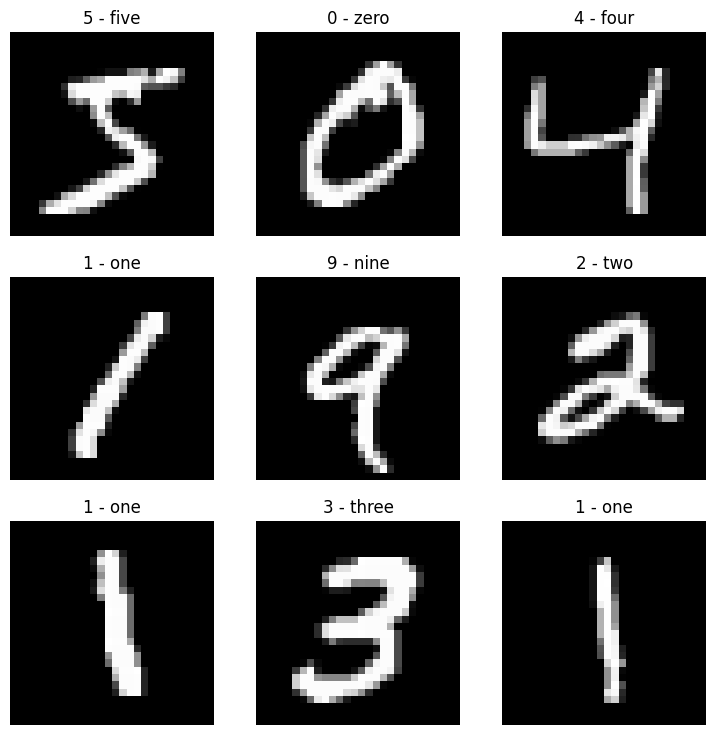

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

image , label = train_data[0]

figure = plt.figure(figsize= (9 , 9))
for i in range(9) :
  plt.subplot(3 , 3 ,i + 1)
  image , label = train_data[i]

  plt.imshow(image.squeeze() , cmap = "gray")
  plt.title(class_name[label])
  plt.axis(False)

In [7]:
image ,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

## 6. Visualize at least 5 different samples of the MNIST training dataset.

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [8]:
from torch.utils.data import DataLoader

Batch_size = 32

train_dataloader = DataLoader(
    dataset = train_data ,
    batch_size = Batch_size ,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_data ,
    batch_size = Batch_size ,
    shuffle = False,
)


In [9]:
len(test_dataloader) , len(train_dataloader)

(313, 1875)

In [10]:
len(test_data[0]) , len(test_dataloader)

(2, 313)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [11]:
import torch
from torch import nn

class MNISTModelV0(nn.Module) :
  def __init__(self , input_shape , hidden_units ,output_shape) :
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels = input_shape ,
            out_channels = hidden_units ,
            kernel_size = 3  ,
            stride = 1 ,
            padding = 1
        ) ,

        nn.ReLU() ,

        nn.Conv2d(
            in_channels = hidden_units ,
            out_channels = hidden_units ,
            kernel_size = 3 ,
            stride = 1  ,
            padding = 1
        )  ,

        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)

    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels = hidden_units ,
            out_channels = hidden_units ,
            kernel_size = 3 ,
            stride = 1 ,
            padding = 1
        ) ,

        nn.ReLU() ,

        nn.Conv2d(hidden_units , hidden_units , 3) ,
        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten() ,
        nn.Linear(in_features = hidden_units*6*6 , out_features = output_shape )
    )

  #create forward pass function
  def forward(self , x) :
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    return x


In [12]:
a,b = train_data[0]
a.shape


torch.Size([1, 28, 28])

In [13]:
torch.manual_seed(42)
model_0 = MNISTModelV0(input_shape=1 , hidden_units = 10 , output_shape= 10).to(device)
model_0

MNISTModelV0(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=360, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [19]:
# importing torchmetrics and accuracy
try :
  import torchmetrics
  from torchmetrics import Accuracy
  print("torchmetrics already exsits.")
except ImportError :
  !pip install -q torchmetrics
  import torchmetrics
  from torchmetrics import Accuracy
  print("torchmetrics installed successfully.")


torchmetrics already exsits.


In [15]:
# create an accuracy function
accuracy_fn = Accuracy(task = "multiclass" , num_classes=10).to(device)

# creating loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters() ,
                            lr = 0.1)

In [16]:
# create a function that print the time of training and test
def print_train_time(start , end , device = device) :
  train_time = end - start

  print(f"The time taken for training in {device} is {train_time:.4f}")
  return train_time

In [17]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
# setup random seed
torch.manual_seed(42)
start_time = timer()
# define epochs
epochs = 5

# create training and testing loops

for epoch in tqdm(range(epochs)) :
  print(f"Epochs : {epoch}\n------------------")

  train_loss = 0
  train_accuracy = 0
  ### Training
  for batch , (x,y) in enumerate(train_dataloader) :
    # set the model to training mode
    model_0.train()

    # set the data into targeted device
    x , y = x.to(device) , y.to(device)
    # print(x.shape)
    # do the forward pass
    y_logits = model_0(x)
    y_preds = torch.argmax(y_logits , dim = 1)

    # calculate the loss
    loss = loss_fn(y_logits , y)
    train_loss += loss

    accuracy = accuracy_fn(y_preds , y)
    train_accuracy += accuracy

    # optimizer the zero grad
    optimizer.zero_grad()

    # loss backward
    loss.backward()
    # optimizer the step
    optimizer.step()

    if batch % 600 == 0 :
        print(f"Looked at : {batch*len(x)}/{len(train_dataloader.dataset)}")

  train_loss /= len(train_dataloader)
  train_accuracy /= len(train_dataloader)

  # testing


  test_loss = 0
  test_acc = 0

  model_0.eval()

  with torch.inference_mode() :
    for x_test , y_test in test_dataloader :
      # set the data to target device

      x_test , y_test = x_test.to(device) , y_test.to(device)

      # do the forard pass
      test_logits = model_0(x_test)
      test_pred = torch.argmax(test_logits , dim = 1)

      # calculate the loss
      test_loss += loss_fn(test_logits , y_test)
      test_acc += accuracy_fn(test_pred.squeeze() , y_test)


    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"Train Loss : {train_loss:4f} | Train Accuracy : {train_accuracy*100:.2f}% | Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc*100:.2f}%")
  print("\n")

end_time = timer()

train_time_gpu = print_train_time(start_time , end_time)


  0%|          | 0/5 [00:00<?, ?it/s]

Epochs : 0
------------------
Looked at : 0/60000
Looked at : 19200/60000
Looked at : 38400/60000
Looked at : 57600/60000
Train Loss : 0.256283 | Train Accuracy : 91.56% | Test Loss : 0.0663 | Test Accuracy : 97.88%


Epochs : 1
------------------
Looked at : 0/60000
Looked at : 19200/60000
Looked at : 38400/60000
Looked at : 57600/60000
Train Loss : 0.067319 | Train Accuracy : 97.89% | Test Loss : 0.0465 | Test Accuracy : 98.41%


Epochs : 2
------------------
Looked at : 0/60000
Looked at : 19200/60000
Looked at : 38400/60000
Looked at : 57600/60000
Train Loss : 0.054161 | Train Accuracy : 98.33% | Test Loss : 0.0469 | Test Accuracy : 98.46%


Epochs : 3
------------------
Looked at : 0/60000
Looked at : 19200/60000
Looked at : 38400/60000
Looked at : 57600/60000
Train Loss : 0.045851 | Train Accuracy : 98.55% | Test Loss : 0.0401 | Test Accuracy : 98.68%


Epochs : 4
------------------
Looked at : 0/60000
Looked at : 19200/60000
Looked at : 38400/60000
Looked at : 57600/60000
Train 

In [18]:
len(train_dataloader)

1875

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?